# IDSC 2025 — Glaucoma Detection Pipeline
Run cells **top to bottom**. Each cell builds on the previous one.

## 📦 Cell 1 — Install Dependencies

In [ ]:
!pip install timm>=0.9.12 xgboost>=2.0.0 opencv-python-headless

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px

## 🔗 Cell 2 — Mount Google Drive & Extract Data

In [ ]:
import gdown
from zipfile import ZipFile

file_id = "1cnc1M5MeYqXxBBRccu_FeTZhx6aCKQUy"
output = "Data.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

# Extract
with ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("✅ Data extracted!")

Downloading...
From (original): https://drive.google.com/uc?id=1cnc1M5MeYqXxBBRccu_FeTZhx6aCKQUy
From (redirected): https://drive.google.com/uc?id=1cnc1M5MeYqXxBBRccu_FeTZhx6aCKQUy&confirm=t&uuid=fafa4c80-67df-4521-b48f-067bd4fee2e0
To: /content/Data.zip
100%|██████████| 132M/132M [00:05<00:00, 23.4MB/s]


✅ Data extracted!


## ⚙️ Cell 3 — Config

In [ ]:
import os
import random
import numpy as np
import torch

# ─── PATHS ──────────────────────────────────────────────────────────────
ROOT_DIR        = "/content"
DATA_INPUT_ROOT = "/content/"
CSV_PATH        = os.path.join(DATA_INPUT_ROOT, "Labels.csv")
DEV_CSV         = os.path.join(DATA_INPUT_ROOT, "dev_set.csv")
TEST_CSV        = os.path.join(DATA_INPUT_ROOT, "test_set.csv")
IMG_DIR         = os.path.join(DATA_INPUT_ROOT, "Images")
CHECKPOINT_DIR  = "/content/checkpoints"
OUTPUT_DIR      = "/content/outputs"
XAI_DIR         = os.path.join(OUTPUT_DIR, "xai")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR,     exist_ok=True)
os.makedirs(XAI_DIR,        exist_ok=True)

# ─── DATA SPLIT ─────────────────────────────────────────────────────────
HOLDOUT_TEST_SIZE = 0.20
N_FOLDS           = 5
RANDOM_SEED       = 42

# ─── COLUMN NAMES ───────────────────────────────────────────────────────
LABEL_COL   = "Label"
PATIENT_COL = "Patient"
IMAGE_COL   = "Image Name"
QUALITY_COL = "Quality Score"
QUALITY_MIN = 1.0
QUALITY_MAX = 10.0

# ─── IMAGE ──────────────────────────────────────────────────────────────
IMG_SIZE       = 300
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]

# ─── TRAINING ───────────────────────────────────────────────────────────
BATCH_SIZE     = 16
NUM_WORKERS    = 2      # keep at 2 for Colab stability
PIN_MEMORY     = True
EPOCHS         = 30
LR             = 3e-4
WEIGHT_DECAY   = 1e-4
PATIENCE       = 7
UNFREEZE_EPOCH = 5

# ─── MODEL ──────────────────────────────────────────────────────────────
BACKBONE          = "tf_efficientnet_b3"
ATTENTION_REDUCE  = 256
DROPOUT           = 0.4

# ─── SVM (nama konsisten dengan classifier yang digunakan) ──────────────
SVM_PARAMS = {
    "kernel"      : "rbf",
    "C"           : 1.0,
    "gamma"       : "scale",
    "probability" : True,
    "random_state": RANDOM_SEED,
}

# ─── SEED (dipindahkan ke sini agar seed_worker tersedia sejak Cell 4) ──
def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(RANDOM_SEED)

# Generator & worker init untuk DataLoader (butuh didefinisikan sebelum Cell 4)
g_seed = torch.Generator()
g_seed.manual_seed(RANDOM_SEED)

def seed_worker(worker_id: int):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

print("✓ Config loaded")
print(f"  ROOT_DIR : {ROOT_DIR}")
print(f"  IMG_DIR  : {IMG_DIR}")
print(f"  CSV_PATH : {CSV_PATH}")
print(f"  Exists   : IMG={os.path.isdir(IMG_DIR)}, CSV={os.path.isfile(CSV_PATH)}")


✓ Config loaded
  ROOT_DIR : /content
  IMG_DIR  : /content/Images
  CSV_PATH : /content/Labels.csv
  Exists   : IMG=True, CSV=False


## 🗂️ Cell 4 — Dataset

In [ ]:
import cv2
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupKFold, GroupShuffleSplit


# ── Image preprocessing ──────────────────────────────────────────────────

def crop_black_border(img_np: np.ndarray, threshold: int = 10) -> np.ndarray:
    gray   = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    mask   = gray > threshold
    coords = np.argwhere(mask)
    if coords.size == 0:
        return img_np
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img_np[y0:y1, x0:x1]

def square_pad(img_np: np.ndarray) -> np.ndarray:
    h, w   = img_np.shape[:2]
    diff   = abs(h - w)
    p1, p2 = diff // 2, diff - diff // 2
    if h < w:
        img_np = np.pad(img_np, ((p1, p2), (0, 0), (0, 0)), mode='constant')
    elif w < h:
        img_np = np.pad(img_np, ((0, 0), (p1, p2), (0, 0)), mode='constant')
    return img_np

def preprocess_image(img_path: str) -> Image.Image:
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Crop black border
    img = crop_black_border(img)

    # CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    lab = cv2.merge((cl, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Padding
    img = square_pad(img)

    return Image.fromarray(img)


# ── Transforms ───────────────────────────────────────────────────────────

def get_train_transforms():
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.RandomCrop(IMG_SIZE, padding=16),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def get_val_transforms():
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

# ── Dataset class ────────────────────────────────────────────────────────

class HYGDDataset(Dataset):
    LABEL_MAP = {"GON+": 1, "GON-": 0}

    def __init__(self, df, img_dir, transform, is_train=True):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.is_train  = is_train
        self.df["q_norm"] = (
            (self.df[QUALITY_COL] - QUALITY_MIN) / (QUALITY_MAX - QUALITY_MIN)
        ).clip(0.0, 1.0)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row[IMAGE_COL])
        tensor   = self.transform(preprocess_image(img_path))
        label    = torch.tensor(self.LABEL_MAP[row[LABEL_COL]], dtype=torch.long)
        q_norm   = torch.tensor(row["q_norm"], dtype=torch.float32)
        return tensor, q_norm, label


# ── Holdout split ────────────────────────────────────────────────────────

def load_dataframe(csv_path=CSV_PATH):
    df = pd.read_csv(csv_path)
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
    df.columns = df.columns.str.strip()
    df[QUALITY_COL] = df[QUALITY_COL].astype(float)
    df[PATIENT_COL] = df[PATIENT_COL].astype(str)
    return df


def _print_split_info(dev_df, test_df):
    print(f"  Dev  set: {len(dev_df):4d} gambar | "
          f"{dev_df[PATIENT_COL].nunique():3d} pasien | "
          f"{dev_df[LABEL_COL].value_counts().to_dict()}")
    print(f"  Test set: {len(test_df):4d} gambar | "
          f"{test_df[PATIENT_COL].nunique():3d} pasien | "
          f"{test_df[LABEL_COL].value_counts().to_dict()}")


def split_holdout(df):
    if os.path.exists(DEV_CSV) and os.path.exists(TEST_CSV):
        print("[Split] Memuat split yang sudah ada dari cache...")
        dev_df  = pd.read_csv(DEV_CSV)
        test_df = pd.read_csv(TEST_CSV)
        dev_df[PATIENT_COL]  = dev_df[PATIENT_COL].astype(str)
        test_df[PATIENT_COL] = test_df[PATIENT_COL].astype(str)
        _print_split_info(dev_df, test_df)
        return dev_df, test_df

    patient_summary = (
        df.groupby(PATIENT_COL)[LABEL_COL].first().reset_index()
    )
    gss = GroupShuffleSplit(n_splits=1, test_size=HOLDOUT_TEST_SIZE, random_state=RANDOM_SEED)
    dev_pat_idx, test_pat_idx = next(gss.split(
        patient_summary, patient_summary[LABEL_COL], groups=patient_summary[PATIENT_COL]
    ))

    dev_patients  = set(patient_summary.iloc[dev_pat_idx][PATIENT_COL])
    test_patients = set(patient_summary.iloc[test_pat_idx][PATIENT_COL])

    dev_df  = df[df[PATIENT_COL].isin(dev_patients)].reset_index(drop=True)
    test_df = df[df[PATIENT_COL].isin(test_patients)].reset_index(drop=True)

    dev_df.to_csv(DEV_CSV,   index=False)
    test_df.to_csv(TEST_CSV, index=False)
    print("[Split] Holdout split BARU dibuat & disimpan ke cache.")
    _print_split_info(dev_df, test_df)
    return dev_df, test_df


# ── K-Fold DataLoaders ───────────────────────────────────────────────────

def get_fold_dataloaders(dev_df, fold_idx, img_dir, batch_size=BATCH_SIZE):
    gkf    = GroupKFold(n_splits=N_FOLDS)
    groups = dev_df[PATIENT_COL].values
    splits = list(gkf.split(dev_df, dev_df[LABEL_COL], groups))

    train_idx, val_idx = splits[fold_idx]
    train_df = dev_df.iloc[train_idx]
    val_df   = dev_df.iloc[val_idx]

    train_ds = HYGDDataset(train_df, img_dir, get_train_transforms(), is_train=True)
    val_ds   = HYGDDataset(val_df,   img_dir, get_val_transforms(),   is_train=False)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
        worker_init_fn = seed_worker, generator = g_seed
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        worker_init_fn = seed_worker, generator = g_seed
    )
    return train_loader, val_loader, train_df, val_df


def get_test_dataloader(test_df, img_dir, batch_size=BATCH_SIZE * 2):
    test_ds = HYGDDataset(test_df, img_dir, get_val_transforms(), is_train=False)
    return DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        worker_init_fn = seed_worker, generator = g_seed
    )


def get_class_weights(train_df):
    counts = train_df[LABEL_COL].value_counts()
    n_neg  = counts.get("GON-", 1)
    n_pos  = counts.get("GON+", 1)
    total  = n_neg + n_pos
    return torch.tensor([total / (2 * n_neg), total / (2 * n_pos)], dtype=torch.float32)


print("✅ Dataset functions defined.")

✅ Dataset functions defined.


## 🧠 Cell 5 — Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(in_channels // reduction, 1)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels),
        )

    def forward(self, x):
        avg   = F.adaptive_avg_pool2d(x, 1)
        mx    = F.adaptive_max_pool2d(x, 1)
        scale = torch.sigmoid(self.mlp(avg) + self.mlp(mx))
        return x * scale.unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=(kernel_size - 1) // 2, bias=False)

    def forward(self, x):
        avg   = x.mean(dim=1, keepdim=True)
        mx    = x.max(dim=1, keepdim=True).values
        scale = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * scale


class HybridAttention(nn.Module):
    def __init__(self, in_channels, reduced_channels=ATTENTION_REDUCE):
        super().__init__()
        self.reduce = nn.Sequential(
            nn.Conv2d(in_channels, reduced_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(reduced_channels),
            nn.ReLU(inplace=True),
        )
        self.channel_att = ChannelAttention(reduced_channels)
        self.spatial_att = SpatialAttention()

    def forward(self, x):
        x_r = self.reduce(x)
        return torch.cat([self.channel_att(x_r), self.spatial_att(x_r)], dim=1)


class NFResNetHybrid(nn.Module):
    def __init__(self, backbone_name=BACKBONE, pretrained=True,
                 reduced_channels=ATTENTION_REDUCE, dropout=DROPOUT):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained, num_classes=0, global_pool="",
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            c_out = self.backbone(dummy).shape[1]

        self.attention  = HybridAttention(c_out, reduced_channels)
        self.gap_dim    = 2 * reduced_channels
        self.fusion_dim = self.gap_dim + 1

        self.head = nn.Sequential(
            nn.LayerNorm(self.fusion_dim),
            nn.Dropout(dropout),
            nn.Linear(self.fusion_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 2),
        )
        self._freeze_backbone(True)

    def _freeze_backbone(self, freeze):
        for p in self.backbone.parameters():
            p.requires_grad = not freeze

    def unfreeze_backbone(self):
        self._freeze_backbone(False)

    def extract_features(self, x, q_norm):
        feat_map = self.backbone(x)
        attn_out = self.attention(feat_map)
        f_gap    = attn_out.mean(dim=[2, 3])
        return torch.cat([f_gap, q_norm.unsqueeze(1)], dim=1)

    def forward(self, x, q_norm):
        v_fusion = self.extract_features(x, q_norm)
        return self.head(v_fusion), v_fusion


def build_model(pretrained=True):
    model = NFResNetHybrid(pretrained=pretrained)
    print(f"[Model] Backbone  : {BACKBONE}")
    print(f"[Model] GAP dim   : {model.gap_dim}")
    print(f"[Model] Fusion dim: {model.fusion_dim}")
    print(f"[Model] Params    : {sum(p.numel() for p in model.parameters()):,}")
    return model


print("✅ Model defined.")

✅ Model defined.


## 🏋️ Cell 6 — Trainer

In [ ]:
import time
from torch.amp import GradScaler, autocast          # REVISI: torch.amp (bukan torch.cuda.amp)
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score, f1_score


def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "auc"    : roc_auc_score(y_true, y_prob),
        "acc"    : accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "f1"     : f1_score(y_true, y_pred, zero_division=0),
    }


def build_scheduler(optimizer, num_epochs, warmup_epochs=2):
    from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
    warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
    cosine = CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs, eta_min=1e-6)
    return SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs])


def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    losses, y_true_list, y_prob_list = [], [], []

    for imgs, q_norms, labels in loader:
        imgs    = imgs.to(device,    non_blocking=True)
        q_norms = q_norms.to(device, non_blocking=True)
        labels  = labels.to(device,  non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):                          # REVISI: tambah device_type
            logits, _ = model(imgs, q_norms)
            loss      = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        probs = torch.softmax(logits.detach(), dim=1)[:, 1].cpu().numpy()
        losses.append(loss.item())
        y_true_list.extend(labels.cpu().numpy())
        y_prob_list.extend(probs)

    m = compute_metrics(np.array(y_true_list), np.array(y_prob_list))
    m["loss"] = float(np.mean(losses))
    return m


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    losses, y_true_list, y_prob_list = [], [], []

    for imgs, q_norms, labels in loader:
        imgs    = imgs.to(device,    non_blocking=True)
        q_norms = q_norms.to(device, non_blocking=True)
        labels  = labels.to(device,  non_blocking=True)

        with autocast("cuda"):                          # REVISI: tambah device_type
            logits, _ = model(imgs, q_norms)
            loss      = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        losses.append(loss.item())
        y_true_list.extend(labels.cpu().numpy())
        y_prob_list.extend(probs)

    m = compute_metrics(np.array(y_true_list), np.array(y_prob_list))
    m["loss"] = float(np.mean(losses))
    return m


class EarlyStopping:
    def __init__(self, patience=PATIENCE):
        self.patience  = patience
        self.best      = -float("inf")
        self.counter   = 0
        self.triggered = False

    def step(self, value):
        if value > self.best:
            self.best    = value
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
            return False


def train_fold(model, train_loader, val_loader, class_weights, fold_idx, device):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY,
    )
    scheduler  = build_scheduler(optimizer, EPOCHS)
    scaler     = GradScaler("cuda")                     # REVISI: tambah device_type
    stopper    = EarlyStopping(PATIENCE)
    ckpt_path  = os.path.join(CHECKPOINT_DIR, f"fold{fold_idx}_best.pth")
    history    = {"train": [], "val": []}
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        if epoch == UNFREEZE_EPOCH:
            model.unfreeze_backbone()
            optimizer = torch.optim.AdamW(
                model.parameters(), lr=LR / 10, weight_decay=WEIGHT_DECAY,
            )
            scheduler = build_scheduler(optimizer, EPOCHS - epoch + 1)
            print(f"\n[Fold {fold_idx}] Backbone di-unfreeze pada epoch {epoch}")

        train_m = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        val_m   = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step()

        history["train"].append(train_m)
        history["val"].append(val_m)

        print(
            f"[Fold {fold_idx} | Ep {epoch:02d}/{EPOCHS}] "
            f"Train Loss={train_m['loss']:.4f} AUC={train_m['auc']:.4f} | "
            f"Val Loss={val_m['loss']:.4f} AUC={val_m['auc']:.4f} "
            f"F1={val_m['f1']:.4f} BalAcc={val_m['bal_acc']:.4f} "
            f"[{time.time()-t0:.1f}s]"
        )

        if stopper.step(val_m["auc"]):
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(best_state, ckpt_path)
            print(f"  ✓ Best AUC={stopper.best:.4f} → checkpoint disimpan.")

        if stopper.triggered:
            print(f"[Fold {fold_idx}] Early stopping pada epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    print(f"\n[Fold {fold_idx}] Selesai. Best Val AUC = {stopper.best:.4f}\n")
    return model, history


print("✅ Trainer defined.")


✅ Trainer defined.


## 🌲 Cell 7 — SVM Classifier

In [ ]:
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


@torch.no_grad()
def extract_features(model, loader, device):
    model.eval()
    all_feats, all_labels = [], []

    for imgs, q_norms, labels in loader:
        imgs    = imgs.to(device,    non_blocking=True)
        q_norms = q_norms.to(device, non_blocking=True)
        with autocast("cuda"):                          # REVISI: tambah device_type
            v_fusion = model.extract_features(imgs, q_norms)
        all_feats.append(v_fusion.float().cpu().numpy())
        all_labels.append(labels.numpy())

    return np.concatenate(all_feats), np.concatenate(all_labels)


def train_svm(X_train, y_train, X_val, y_val, fold_idx):    # REVISI: nama fungsi train_svm
    # Hitung class weight otomatis untuk menangani imbalance
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    cw    = {0: 1.0, 1: n_neg / n_pos if n_pos > 0 else 1.0}

    # Pipeline: StandardScaler → SVM
    # StandardScaler wajib karena SVM sensitif terhadap skala fitur
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(
            kernel       = "rbf",
            C            = SVM_PARAMS["C"],
            gamma        = SVM_PARAMS["gamma"],
            class_weight = cw,
            probability  = True,       # wajib True agar bisa predict_proba
            random_state = RANDOM_SEED,
        )),
    ])

    clf.fit(X_train, y_train)

    # Simpan dengan joblib
    save_path = os.path.join(CHECKPOINT_DIR, f"svm_fold{fold_idx}.joblib")  # REVISI: svm_ prefix
    joblib.dump(clf, save_path)

    y_prob = clf.predict_proba(X_val)[:, 1]
    auc    = roc_auc_score(y_val, y_prob)
    report = classification_report(y_val, (y_prob >= 0.5).astype(int),
                                   target_names=["GON-", "GON+"])
    print(f"\n[SVM Fold {fold_idx}] Val AUC = {auc:.4f}")
    print(f"[SVM Fold {fold_idx}] Model disimpan: {save_path}")
    print(report)
    return clf, auc


def plot_confusion_matrix(y_true, y_pred, fold_idx, save_dir=OUTPUT_DIR):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["GON-", "GON+"])
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix – Fold {fold_idx} (Val)")
    plt.tight_layout()
    path = os.path.join(save_dir, f"confusion_matrix_fold{fold_idx}.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"[Plot] Confusion matrix disimpan: {path}")


print("✅ SVM functions defined.")


✅ SVM functions defined.


## 🔬 Cell 8 — Grad-CAM++

In [ ]:
import matplotlib.cm as cm_module


class GradCAMPlusPlus:
    def __init__(self, model, device):
        self.model  = model.eval()
        self.device = device
        self._hooks = []
        self._fmaps = None
        self._grads = None

    def _register_hooks(self, target_layer):
        self._clear_hooks()
        def fwd_hook(module, inp, out): self._fmaps = out.detach()
        def bwd_hook(module, grad_in, grad_out): self._grads = grad_out[0].detach()
        self._hooks.append(target_layer.register_forward_hook(fwd_hook))
        self._hooks.append(target_layer.register_full_backward_hook(bwd_hook))

    def _clear_hooks(self):
        for h in self._hooks: h.remove()
        self._hooks = []

    def generate(self, img_tensor, q_norm, class_idx=1):
        # REVISI: Hook ke last conv block backbone (lebih representatif)
        # daripada hook ke HybridAttention output yang sudah di-concat
        target_layer = self.model.backbone.blocks[-1]
        self._register_hooks(target_layer)

        self.model.zero_grad()
        img_tensor = img_tensor.to(self.device)
        q_norm     = q_norm.to(self.device)
        logits, _  = self.model(img_tensor, q_norm)
        self.model.zero_grad()
        logits[0, class_idx].backward()

        grads  = self._grads
        fmaps  = self._fmaps
        grads2 = grads ** 2
        grads3 = grads ** 3
        alpha  = grads2 / (2 * grads2 + (fmaps * grads3).sum(dim=[2,3], keepdim=True) + 1e-8)
        weights = (alpha * F.relu(grads)).sum(dim=[2,3], keepdim=True)
        cam    = F.relu((weights * fmaps).sum(dim=1, keepdim=True)).squeeze().cpu().numpy()

        cam_min, cam_max = cam.min(), cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        self._clear_hooks()
        return cam

    def overlay_heatmap(self, cam, original_img, alpha=0.45):
        h, w        = original_img.shape[:2]
        cam_resized = cv2.resize(cam, (w, h), interpolation=cv2.INTER_LINEAR)
        heatmap     = (cm_module.jet(cam_resized)[:, :, :3] * 255).astype(np.uint8)
        return (
            (1 - alpha) * original_img.astype(np.float32) +
            alpha       * heatmap.astype(np.float32)
        ).clip(0, 255).astype(np.uint8)


def visualize_gradcam(model, img_path, q_norm_val, device,
                      class_idx=1, save_path=None, label_str=""):
    transform  = get_val_transforms()
    pil_img    = preprocess_image(img_path)
    img_t      = transform(pil_img).unsqueeze(0)
    q_t        = torch.tensor([q_norm_val], dtype=torch.float32)

    gradcam    = GradCAMPlusPlus(model, device)
    cam        = gradcam.generate(img_t, q_t, class_idx=class_idx)
    original_np = np.array(pil_img)
    overlay    = gradcam.overlay_heatmap(cam, original_np)

    with torch.no_grad():
        logits, _ = model(img_t.to(device), q_t.to(device))
        prob_pos  = torch.softmax(logits, dim=1)[0, 1].item()

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(original_np);   axes[0].set_title("Gambar Asli");         axes[0].axis("off")
    axes[1].imshow(cam, cmap="jet"); axes[1].set_title("Grad-CAM++ Heatmap"); axes[1].axis("off")
    axes[2].imshow(overlay);       axes[2].set_title("Overlay");             axes[2].axis("off")

    q_real = q_norm_val * (QUALITY_MAX - QUALITY_MIN) + QUALITY_MIN
    fig.suptitle(
        f"{os.path.basename(img_path)} | Label: {label_str} | "
        f"P(GON+)={prob_pos:.3f} | Q_score={q_real:.2f}", fontsize=11
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"[GradCAM] Disimpan: {save_path}")
    else:
        plt.show()


def batch_visualize_gradcam(model, sample_df, img_dir, device,
                             n_samples=6, save_dir=XAI_DIR, fold_idx=0):
    pos = sample_df[sample_df[LABEL_COL] == "GON+"].sample(
        min(n_samples // 2, (sample_df[LABEL_COL] == "GON+").sum()),
        random_state=RANDOM_SEED
    )
    neg = sample_df[sample_df[LABEL_COL] == "GON-"].sample(
        min(n_samples // 2, (sample_df[LABEL_COL] == "GON-").sum()),
        random_state=RANDOM_SEED
    )
    selected = pd.concat([pos, neg])

    for _, row in selected.iterrows():
        img_name = row[IMAGE_COL]
        q_norm   = float((row[QUALITY_COL] - QUALITY_MIN) / (QUALITY_MAX - QUALITY_MIN))
        img_path = os.path.join(img_dir, img_name)
        if not os.path.exists(img_path):
            print(f"[GradCAM] Tidak ditemukan: {img_path}")
            continue
        save_path = os.path.join(save_dir, f"gradcam_fold{fold_idx}_{img_name.replace('.jpg','')}.png")
        visualize_gradcam(
            model=model, img_path=img_path, q_norm_val=q_norm,
            device=device, save_path=save_path, label_str=row[LABEL_COL],
        )


print("✅ Grad-CAM++ defined.")


✅ Grad-CAM++ defined.


## 🚀 Cell 9 — Run Training


[Device] Using: cuda

[Data] Total gambar : 747
[Data] Total pasien : 288
[Data] Label dist   : {'GON+': 548, 'GON-': 199}
[Split] Memuat split yang sudah ada dari cache...
  Dev  set:  615 gambar | 230 pasien | {'GON+': 462, 'GON-': 153}
  Test set:  132 gambar |  58 pasien | {'GON+': 86, 'GON-': 46}

[Info] Test set (132 gambar) dikunci. Hanya dev set (615 gambar) yang dipakai training.


  FOLD 1 / 5
[Fold 0] Train: 492 | Val: 123
[Fold 0] Class weights: [1.9069767 0.677686 ]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

[Model] Backbone  : tf_efficientnet_b3
[Model] GAP dim   : 512
[Model] Fusion dim: 513
[Model] Params    : 11,165,598
[Fold 0 | Ep 01/30] Train Loss=0.6956 AUC=0.5553 | Val Loss=0.6113 AUC=0.8756 F1=0.8796 BalAcc=0.7576 [133.7s]
  ✓ Best AUC=0.8756 → checkpoint disimpan.
[Fold 0 | Ep 02/30] Train Loss=0.4744 AUC=0.8956 | Val Loss=0.2355 AUC=0.9912 F1=0.9746 BalAcc=0.9432 [116.1s]
  ✓ Best AUC=0.9912 → checkpoint disimpan.
[Fold 0 | Ep 03/30] Train Loss=0.2791 AUC=0.9521 | Val Loss=0.2460 AUC=0.9971 F1=0.9412 BalAcc=0.9444 [118.0s]
  ✓ Best AUC=0.9971 → checkpoint disimpan.
[Fold 0 | Ep 04/30] Train Loss=0.2282 AUC=0.9683 | Val Loss=0.1110 AUC=0.9941 F1=0.9700 BalAcc=0.9066 [116.9s]

[Fold 0] Backbone di-unfreeze pada epoch 5
[Fold 0 | Ep 05/30] Train Loss=0.2538 AUC=0.9639 | Val Loss=0.1281 AUC=0.9901 F1=0.9703 BalAcc=0.8908 [127.7s]
[Fold 0 | Ep 06/30] Train Loss=0.2283 AUC=0.9703 | Val Loss=0.1035 AUC=0.9958 F1=0.9802 BalAcc=0.9167 [120.1s]
[Fold 0 | Ep 07/30] Train Loss=0.2044 AUC=0

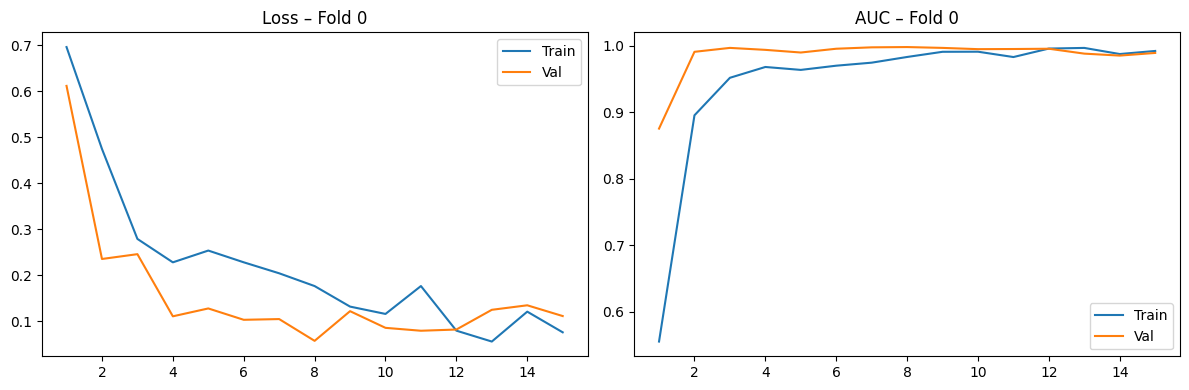


[Fold 0] Mengekstrak fitur untuk SVM...

[SVM Fold 0] Val AUC = 0.9983
[SVM Fold 0] Model disimpan: /content/checkpoints/svm_fold0.joblib
              precision    recall  f1-score   support

        GON-       1.00      0.88      0.93        24
        GON+       0.97      1.00      0.99        99

    accuracy                           0.98       123
   macro avg       0.99      0.94      0.96       123
weighted avg       0.98      0.98      0.97       123

[Plot] Confusion matrix disimpan: /content/outputs/confusion_matrix_fold0.png

[Fold 0] Menghasilkan Grad-CAM++ visualisasi...
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold0_150_2.png
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold0_116_0.png
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold0_185_2.png
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold0_237_1.png
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold0_270_1.png
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold0_193_0.png

  FOLD 2 / 5
[Fo

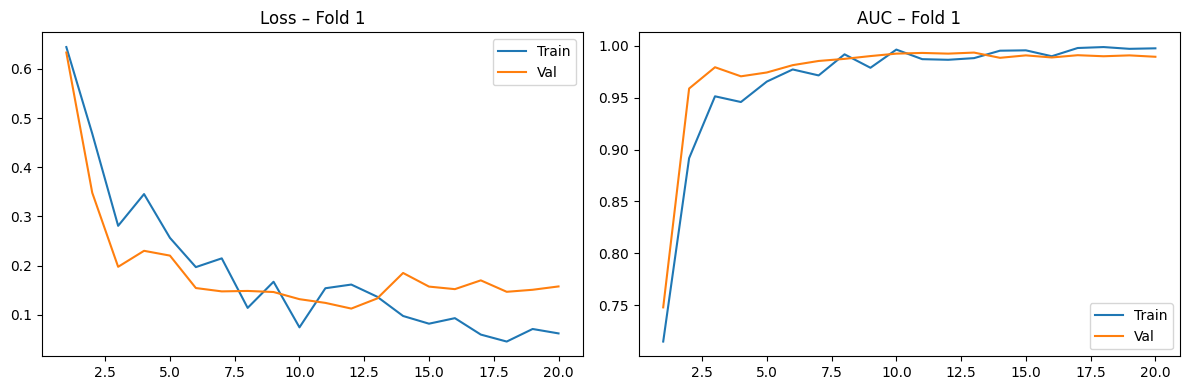


[Fold 1] Mengekstrak fitur untuk SVM...

[SVM Fold 1] Val AUC = 0.9822
[SVM Fold 1] Model disimpan: /content/checkpoints/svm_fold1.joblib
              precision    recall  f1-score   support

        GON-       0.83      0.91      0.87        33
        GON+       0.97      0.93      0.95        90

    accuracy                           0.93       123
   macro avg       0.90      0.92      0.91       123
weighted avg       0.93      0.93      0.93       123

[Plot] Confusion matrix disimpan: /content/outputs/confusion_matrix_fold1.png

[Fold 1] Menghasilkan Grad-CAM++ visualisasi...
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold1_63_5.png
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold1_36_9.png
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold1_108_2.png
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold1_287_1.png
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold1_234_0.png
[GradCAM] Disimpan: /content/outputs/xai/gradcam_fold1_272_0.png

  FOLD 3 / 5
[Fold

In [ ]:
# ── Config ───────────────────────────────────────────────────────────────
RUN_SVM     = True   # REVISI: nama konsisten (bukan RUN_XGB)
RUN_XAI     = True   # set False to skip Grad-CAM++
FOLD_TO_RUN = -1     # -1 = all folds; 0..4 = single fold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[Device] Using: {device}")

# ── 1. Load data ─────────────────────────────────────────────────────────
df_full = load_dataframe(CSV_PATH)
print(f"\n[Data] Total gambar : {len(df_full)}")
print(f"[Data] Total pasien : {df_full[PATIENT_COL].nunique()}")
print(f"[Data] Label dist   : {df_full[LABEL_COL].value_counts().to_dict()}")

dev_df, test_df = split_holdout(df_full)
print(f"\n[Info] Test set ({len(test_df)} gambar) dikunci. "
      f"Hanya dev set ({len(dev_df)} gambar) yang dipakai training.\n")

# ── 2. Training loop ─────────────────────────────────────────────────────
fold_indices = [FOLD_TO_RUN] if FOLD_TO_RUN >= 0 else list(range(N_FOLDS))
fold_results = []

for fold_idx in fold_indices:
    print(f"\n{'='*55}")
    print(f"  FOLD {fold_idx + 1} / {N_FOLDS}")
    print(f"{'='*55}")

    train_loader, val_loader, train_df, val_df = get_fold_dataloaders(dev_df, fold_idx, IMG_DIR)
    class_weights = get_class_weights(train_df)
    print(f"[Fold {fold_idx}] Train: {len(train_df)} | Val: {len(val_df)}")
    print(f"[Fold {fold_idx}] Class weights: {class_weights.numpy()}")

    model = build_model(pretrained=True).to(device)
    model, history = train_fold(model, train_loader, val_loader, class_weights, fold_idx, device)

    # ── Plot training history ──────────────────────────────────────────
    epochs = range(1, len(history["train"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, [m["loss"] for m in history["train"]], label="Train")
    axes[0].plot(epochs, [m["loss"] for m in history["val"]],   label="Val")
    axes[0].set_title(f"Loss – Fold {fold_idx}"); axes[0].legend()
    axes[1].plot(epochs, [m["auc"]  for m in history["train"]], label="Train")
    axes[1].plot(epochs, [m["auc"]  for m in history["val"]],   label="Val")
    axes[1].set_title(f"AUC – Fold {fold_idx}");  axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"history_fold{fold_idx}.png"), dpi=150)
    plt.show()

    # ── SVM ───────────────────────────────────────────────────────────
    if RUN_SVM:                                         # REVISI: RUN_SVM
        print(f"\n[Fold {fold_idx}] Mengekstrak fitur untuk SVM...")
        X_train, y_train = extract_features(model, train_loader, device)
        X_val,   y_val   = extract_features(model, val_loader,   device)
        clf, svm_auc     = train_svm(X_train, y_train, X_val, y_val, fold_idx)  # REVISI: train_svm
        y_prob = clf.predict_proba(X_val)[:, 1]
        plot_confusion_matrix(y_val, (y_prob >= 0.5).astype(int), fold_idx)
        fold_results.append({"fold": fold_idx, "svm_auc": round(svm_auc, 4),   # REVISI: svm_auc
                              "n_train": len(y_train), "n_val": len(y_val)})

    # ── Grad-CAM++ ────────────────────────────────────────────────────
    if RUN_XAI:
        print(f"\n[Fold {fold_idx}] Menghasilkan Grad-CAM++ visualisasi...")
        batch_visualize_gradcam(model=model, sample_df=val_df, img_dir=IMG_DIR,
                                device=device, n_samples=6, fold_idx=fold_idx)

# ── Summary ───────────────────────────────────────────────────────────────
if fold_results:
    df_res = pd.DataFrame(fold_results)
    df_res.to_csv(os.path.join(OUTPUT_DIR, "fold_results.csv"), index=False)
    print("\n" + "="*55)
    print("  FOLD RESULTS")
    print("="*55)
    print(df_res.to_string(index=False))
    if len(df_res) > 1:
        print(f"\n  Mean AUC : {df_res['svm_auc'].mean():.4f} ± {df_res['svm_auc'].std():.4f}")  # REVISI
    print("="*55)

print(f"\n[Pipeline] Selesai! Output di: {OUTPUT_DIR}")


In [ ]:
import os, json, joblib, torch
import numpy as np

EXPORT_DIR = os.path.join(ROOT_DIR, "streamlit_models")  # REVISI: ROOT_DIR sudah didefinisikan
os.makedirs(EXPORT_DIR, exist_ok=True)

print("=" * 60)
print("  EKSPOR MODEL UNTUK STREAMLIT DASHBOARD")
print("=" * 60)

exported_folds = []

for fold_idx in range(N_FOLDS):
    cnn_src = os.path.join(CHECKPOINT_DIR, f"fold{fold_idx}_best.pth")
    svm_src = os.path.join(CHECKPOINT_DIR, f"svm_fold{fold_idx}.joblib")  # REVISI: svm_ prefix

    cnn_dst = os.path.join(EXPORT_DIR, f"fold{fold_idx}_cnn.pth")
    svm_dst = os.path.join(EXPORT_DIR, f"fold{fold_idx}_svm.joblib")

    if not os.path.exists(cnn_src):
        print(f"  [SKIP] Fold {fold_idx}: CNN checkpoint tidak ditemukan ({cnn_src})")
        continue
    if not os.path.exists(svm_src):
        print(f"  [SKIP] Fold {fold_idx}: SVM checkpoint tidak ditemukan ({svm_src})")
        continue

    # Salin CNN weights
    state = torch.load(cnn_src, map_location="cpu")
    torch.save(state, cnn_dst)

    # Salin SVM pipeline
    svm_pipeline = joblib.load(svm_src)
    joblib.dump(svm_pipeline, svm_dst)

    exported_folds.append(fold_idx)
    print(f"  [OK] Fold {fold_idx} disimpan → {cnn_dst}")
    print(f"           → {svm_dst}")

# ── Simpan konfigurasi model ─────────────────────────────────────────────
config = {
    "backbone"        : BACKBONE,
    "img_size"        : IMG_SIZE,
    "attention_reduce": ATTENTION_REDUCE,
    "dropout"         : DROPOUT,
    "imagenet_mean"   : IMAGENET_MEAN,
    "imagenet_std"    : IMAGENET_STD,
    "quality_min"     : QUALITY_MIN,
    "quality_max"     : QUALITY_MAX,
    "n_folds"         : N_FOLDS,
    "exported_folds"  : exported_folds,
    "threshold"       : 0.5,
    "label_map"       : {"0": "GON-", "1": "GON+"},
}
config_path = os.path.join(EXPORT_DIR, "model_config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"\n  [OK] Konfigurasi disimpan → {config_path}")
print(f"  Total fold diekspor: {len(exported_folds)} / {N_FOLDS}")
print(f"  Folder output      : {EXPORT_DIR}")
print("=" * 60)
print("  ✅ Selesai! Folder 'streamlit_models/' siap digunakan.")
print("     Salin folder ini ke direktori yang sama dengan app.py")
print("=" * 60)


## ⚡ Cell 10 — Run Testing

In [ ]:
import matplotlib.gridspec as gridspec
import joblib
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

def ensemble_predict(img_dir, test_df, device):
    test_loader = get_test_dataloader(test_df, img_dir)
    y_true      = np.array([1 if l == "GON+" else 0
                             for l in test_df[LABEL_COL]])
    all_probs   = []

    for fold_idx in range(N_FOLDS):
        cnn_ckpt = os.path.join(CHECKPOINT_DIR, f"fold{fold_idx}_best.pth")
        xgb_ckpt = os.path.join(CHECKPOINT_DIR, f"svm_fold{fold_idx}.joblib")

        if not os.path.exists(cnn_ckpt) or not os.path.exists(xgb_ckpt):
            print(f"  [Skip] Fold {fold_idx} belum ada checkpoint-nya.")
            continue

        print(f"  [Fold {fold_idx}] Memprediksi test set...")
        model = build_model(pretrained=False).to(device)
        model.load_state_dict(torch.load(cnn_ckpt, map_location=device))

        clf = joblib.load(xgb_ckpt)

        X_test, _ = extract_features(model, test_loader, device)
        y_prob    = clf.predict_proba(X_test)[:, 1]
        all_probs.append(y_prob)

        fold_auc = roc_auc_score(y_true, y_prob)
        print(f"  [Fold {fold_idx}] Per-fold Test AUC = {fold_auc:.4f}")

    if not all_probs:
        raise RuntimeError("Tidak ada checkpoint yang ditemukan!")

    ensemble_probs = np.mean(all_probs, axis=0)
    print(f"\n  Ensemble dari {len(all_probs)} fold model.")
    return y_true, ensemble_probs, all_probs


def plot_results(y_true, y_prob_ens, all_probs):
    y_pred = (y_prob_ens >= 0.5).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "AUC-ROC"    : roc_auc_score(y_true, y_prob_ens),
        "Accuracy"   : accuracy_score(y_true, y_pred),
        "Balanced Acc": balanced_accuracy_score(y_true, y_pred),
        "F1 Score"   : f1_score(y_true, y_pred, zero_division=0),
        "Sensitivity": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
    }

    fig = plt.figure(figsize=(15, 5))
    gs  = gridspec.GridSpec(1, 3)

    ax1 = fig.add_subplot(gs[0])
    ConfusionMatrixDisplay(cm, display_labels=["GON-", "GON+"]).plot(
        ax=ax1, colorbar=False, cmap="Blues")
    ax1.set_title("Confusion Matrix\n(Ensemble – Holdout Test Set)", fontsize=11)

    ax2 = fig.add_subplot(gs[1])
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_probs)))
    for i, prob in enumerate(all_probs):
        fpr_f, tpr_f, _ = roc_curve(y_true, prob)
        ax2.plot(fpr_f, tpr_f, color=colors[i], lw=1, alpha=0.5,
                 label=f"Fold {i} ({auc(fpr_f,tpr_f):.3f})")
    fpr, tpr, _ = roc_curve(y_true, y_prob_ens)
    ax2.plot(fpr, tpr, "k-", lw=2.5, label=f"Ensemble ({auc(fpr,tpr):.4f})")
    ax2.plot([0,1],[0,1],"--", color="gray", lw=1)
    ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
    ax2.set_title("ROC Curve – Holdout Test Set", fontsize=11)
    ax2.legend(fontsize=7, loc="lower right"); ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[2]); ax3.axis("off")
    table_data = [[k, f"{v:.4f}" if isinstance(v, float) else str(v)]
                  for k, v in metrics.items()]
    table = ax3.table(cellText=table_data, colLabels=["Metrik", "Nilai"],
                      loc="center", cellLoc="center")
    table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.2, 1.6)
    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_facecolor("#1976D2"); cell.set_text_props(color="white", fontweight="bold")
        elif r % 2 == 0:
            cell.set_facecolor("#E3F2FD")
    ax3.set_title("Metrik Final – Holdout Test Set", fontsize=11, pad=20)

    plt.suptitle(
        "HYGD Glaucoma GON – Final Holdout Test Evaluation\n"
        f"NF-ResNet + Hybrid Attention + Late Fusion + SVM ({len(all_probs)}-Fold Ensemble)",
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "test_final_result.png")
    plt.savefig(path, dpi=200, bbox_inches="tight"); plt.close()
    print(f"[Plot] Disimpan: {path}")

    print("\n" + classification_report(y_true, y_pred, target_names=["GON-", "GON+"]))

    pd.DataFrame([metrics]).to_csv(
        os.path.join(OUTPUT_DIR, "test_final_metrics.csv"), index=False
    )
    return metrics


# ── Jalankan evaluasi ─────────────────────────────────────────────────────
df_full = load_dataframe()
_, test_df = split_holdout(df_full)

print(f"[Test Set] {len(test_df)} gambar | "
      f"{test_df[LABEL_COL].value_counts().to_dict()}\n")

y_true, ensemble_probs, all_probs = ensemble_predict(IMG_DIR, test_df, device)
metrics = plot_results(y_true, ensemble_probs, all_probs)

print("\n" + "="*50)
print("  HASIL FINAL HOLDOUT TEST SET")
print("="*50)
for k, v in metrics.items():
    print(f"  {k:20s}: {v:.4f}" if isinstance(v, float) else f"  {k:20s}: {v}")
print("\n[Selesai] Output di:", OUTPUT_DIR)

## 🔷 Cell 11 Prediction & Visualization

In [ ]:
"""## 🔍 Cell 10 — Prediksi Interaktif + Visualisasi

Upload foto fundus → langsung keluar prediksi, probabilitas, dan Grad-CAM++ heatmap.
Bisa pakai model dari satu fold tertentu, atau ensemble semua fold yang tersedia.
"""

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from PIL import Image
from google.colab import files
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

# ─── Konfigurasi Cell 10 ─────────────────────────────────────────────────────
USE_ENSEMBLE = True    # True = rata-rata semua fold, False = pakai SINGLE_FOLD saja
SINGLE_FOLD  = 0       # Dipakai hanya jika USE_ENSEMBLE = False
THRESHOLD    = 0.5     # Ambang batas klasifikasi GON+
# ─────────────────────────────────────────────────────────────────────────────


def load_fold_models(device, use_ensemble=True, single_fold=0):
    """Load satu atau semua fold model dari checkpoint."""
    fold_indices = list(range(N_FOLDS)) if use_ensemble else [single_fold]
    models = []
    for fold_idx in fold_indices:
        ckpt = os.path.join(CHECKPOINT_DIR, f"fold{fold_idx}_best.pth")
        if not os.path.exists(ckpt):
            print(f"  [Skip] Checkpoint fold {fold_idx} tidak ditemukan.")
            continue
        m = build_model(pretrained=False).to(device)
        m.load_state_dict(torch.load(ckpt, map_location=device))
        m.eval()
        models.append((fold_idx, m))
        print(f"  ✅ Fold {fold_idx} loaded.")
    if not models:
        raise RuntimeError("Tidak ada checkpoint yang bisa dimuat! Pastikan Cell 9 sudah selesai dijalankan.")
    return models


def predict_single(model, img_path, q_score, device):
    """
    Prediksi satu gambar dengan satu model.
    Return: prob_pos (float), original PIL image
    """
    q_norm  = float((q_score - QUALITY_MIN) / (QUALITY_MAX - QUALITY_MIN))
    q_norm  = max(0.0, min(1.0, q_norm))

    transform = get_val_transforms()
    pil_img   = preprocess_image(img_path)
    img_t     = transform(pil_img).unsqueeze(0).to(device)
    q_t       = torch.tensor([q_norm], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits, _ = model(img_t, q_t)
        probs     = torch.softmax(logits, dim=1)[0]
        prob_neg  = probs[0].item()
        prob_pos  = probs[1].item()

    return prob_neg, prob_pos, q_norm, pil_img


def get_gradcam_overlay(model, img_path, q_norm, device):
    """Jalankan Grad-CAM++ dan return (cam, overlay_np, original_np)."""
    transform   = get_val_transforms()
    pil_img     = preprocess_image(img_path)
    img_t       = transform(pil_img).unsqueeze(0)
    q_t         = torch.tensor([q_norm], dtype=torch.float32)

    gradcam     = GradCAMPlusPlus(model, device)
    cam         = gradcam.generate(img_t, q_t, class_idx=1)
    original_np = np.array(pil_img)
    overlay     = gradcam.overlay_heatmap(cam, original_np)
    return cam, overlay, original_np


def visualize_prediction(img_path, models, q_score, device, save=True):
    """
    Pipeline lengkap: prediksi (ensemble/single) + Grad-CAM++ dari fold terbaik.
    """
    img_name = os.path.basename(img_path)

    # ── 1. Prediksi dari semua model ──────────────────────────────────────
    all_prob_neg, all_prob_pos = [], []
    q_norm = float((q_score - QUALITY_MIN) / (QUALITY_MAX - QUALITY_MIN))
    q_norm = max(0.0, min(1.0, q_norm))

    for fold_idx, model in models:
        prob_neg, prob_pos, _, pil_img = predict_single(model, img_path, q_score, device)
        all_prob_neg.append(prob_neg)
        all_prob_pos.append(prob_pos)

    prob_pos_final = float(np.mean(all_prob_pos))
    prob_neg_final = float(np.mean(all_prob_neg))
    label_pred     = "GON+" if prob_pos_final >= THRESHOLD else "GON-"
    is_positive    = label_pred == "GON+"

    # ── 2. Grad-CAM++ dari model fold pertama yang tersedia ───────────────
    best_model = models[0][1]
    cam, overlay, original_np = get_gradcam_overlay(best_model, img_path, q_norm, device)

    # ── 3. Layout visualisasi ─────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 7))
    fig.patch.set_facecolor("#0f0f0f")

    gs = gridspec.GridSpec(
        2, 4,
        figure=fig,
        left=0.04, right=0.96,
        top=0.82, bottom=0.08,
        wspace=0.35, hspace=0.45
    )

    COLOR_POS  = "#FF4C4C"
    COLOR_NEG  = "#4CAF50"
    COLOR_MAIN = COLOR_POS if is_positive else COLOR_NEG
    LABEL_CLR  = {"GON+": COLOR_POS, "GON-": COLOR_NEG}

    # Panel kiri: original
    ax_orig = fig.add_subplot(gs[:, 0])
    ax_orig.imshow(original_np)
    ax_orig.set_title("📷 Gambar Original", color="white", fontsize=10, pad=8)
    ax_orig.axis("off")
    for spine in ax_orig.spines.values():
        spine.set_edgecolor(COLOR_MAIN); spine.set_linewidth(2)

    # Panel tengah-kiri: heatmap
    ax_heat = fig.add_subplot(gs[:, 1])
    ax_heat.imshow(cam, cmap="jet")
    ax_heat.set_title("🔥 Grad-CAM++ Heatmap", color="white", fontsize=10, pad=8)
    ax_heat.axis("off")

    # Panel tengah-kanan: overlay
    ax_over = fig.add_subplot(gs[:, 2])
    ax_over.imshow(overlay)
    ax_over.set_title("🔎 Overlay", color="white", fontsize=10, pad=8)
    ax_over.axis("off")

    # Panel kanan-atas: probabilitas bar
    ax_bar = fig.add_subplot(gs[0, 3])
    ax_bar.set_facecolor("#1a1a1a")
    bars = ax_bar.barh(
        ["GON-", "GON+"],
        [prob_neg_final, prob_pos_final],
        color=[COLOR_NEG, COLOR_POS],
        height=0.55, edgecolor="white", linewidth=0.5
    )
    ax_bar.set_xlim(0, 1)
    ax_bar.axvline(x=THRESHOLD, color="white", lw=1.2, ls="--", alpha=0.6)
    ax_bar.text(THRESHOLD + 0.02, -0.6, f"threshold\n{THRESHOLD}", color="white",
                fontsize=7, alpha=0.7)
    for bar, val in zip(bars, [prob_neg_final, prob_pos_final]):
        ax_bar.text(min(val + 0.03, 0.95), bar.get_y() + bar.get_height() / 2,
                    f"{val*100:.1f}%", va="center", ha="left",
                    color="white", fontsize=10, fontweight="bold")
    ax_bar.set_xlabel("Probabilitas", color="white", fontsize=8)
    ax_bar.set_title("Distribusi Probabilitas", color="white", fontsize=9)
    ax_bar.tick_params(colors="white", labelsize=8)
    for spine in ax_bar.spines.values():
        spine.set_edgecolor("#444")

    # Panel kanan-bawah: info & verdict
    ax_info = fig.add_subplot(gs[1, 3])
    ax_info.set_facecolor("#1a1a1a")
    ax_info.axis("off")

    verdict_symbol = "⚠️  POSITIF" if is_positive else "✅  NEGATIF"
    verdict_desc   = "Glaucomatous Optic Neuropathy\nterdeteksi." if is_positive \
                     else "Tidak terdeteksi tanda\nGlaucomatous Optic Neuropathy."

    ax_info.text(0.5, 0.90, verdict_symbol,
                 transform=ax_info.transAxes, ha="center", va="top",
                 fontsize=13, fontweight="bold", color=COLOR_MAIN)
    ax_info.text(0.5, 0.68, verdict_desc,
                 transform=ax_info.transAxes, ha="center", va="top",
                 fontsize=8.5, color="lightgray", style="italic")

    separator_y = 0.50
    ax_info.axhline(y=separator_y, xmin=0.05, xmax=0.95,
                    transform=ax_info.transAxes, color="#444", lw=0.8)

    info_lines = [
        ("File",         img_name),
        ("Quality Score", f"{q_score:.1f} / 10.0"),
        ("Mode",         f"Ensemble ({len(models)} fold)" if len(models) > 1 else f"Single (Fold {models[0][0]})"),
        ("P(GON+)",      f"{prob_pos_final*100:.2f}%"),
        ("P(GON-)",      f"{prob_neg_final*100:.2f}%"),
        ("Prediksi",     label_pred),
    ]
    for i, (key, val) in enumerate(info_lines):
        y_pos = 0.44 - i * 0.13
        ax_info.text(0.08, y_pos, f"{key}:",
                     transform=ax_info.transAxes, ha="left", va="top",
                     fontsize=8, color="#aaaaaa")
        color_val = LABEL_CLR.get(val, "white")
        ax_info.text(0.92, y_pos, val,
                     transform=ax_info.transAxes, ha="right", va="top",
                     fontsize=8, fontweight="bold", color=color_val)

    # Title utama
    fig.suptitle(
        f"HYGD Glaucoma GON — Hasil Prediksi: {img_name}",
        color="white", fontsize=13, fontweight="bold", y=0.96
    )

    # Border warna di sekeliling figure
    rect = mpatches.FancyBboxPatch(
        (0.01, 0.01), 0.98, 0.97,
        boxstyle="round,pad=0.01",
        linewidth=2.5, edgecolor=COLOR_MAIN,
        facecolor="none", transform=fig.transFigure
    )
    fig.add_artist(rect)

    plt.rcParams["text.color"] = "white"

    if save:
        save_name = f"predict_{os.path.splitext(img_name)[0]}.png"
        save_path = os.path.join(OUTPUT_DIR, save_name)
        plt.savefig(save_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"[Saved] → {save_path}")

    plt.show()
    plt.close()

    # ── Ringkasan teks ────────────────────────────────────────────────────
    print("\n" + "─"*50)
    print(f"  File         : {img_name}")
    print(f"  Prediksi     : {label_pred}")
    print(f"  P(GON+)      : {prob_pos_final*100:.2f}%")
    print(f"  P(GON-)      : {prob_neg_final*100:.2f}%")
    print(f"  Mode         : {'Ensemble' if len(models) > 1 else 'Single fold'} ({len(models)} model)")
    print("─"*50)

    return label_pred, prob_pos_final


# ─── Load model ──────────────────────────────────────────────────────────────
print("📦 Loading model(s)...\n")
loaded_models = load_fold_models(device, use_ensemble=USE_ENSEMBLE, single_fold=SINGLE_FOLD)
print(f"\n✅ {len(loaded_models)} model siap digunakan.\n")

# ─── Widget UI ───────────────────────────────────────────────────────────────
display(HTML("""
<div style="
    background:#1a1a2e; border:1.5px solid #4a4aff;
    border-radius:10px; padding:14px 20px; margin-bottom:8px;
    font-family:monospace; color:#e0e0ff;">
  <b style="font-size:15px;">🔍 Prediksi Glaukoma Interaktif</b><br>
  <span style="font-size:12px; color:#aaaacc;">
    Atur quality score → upload foto → klik Proses
  </span>
</div>
"""))

# Slider quality score
slider_qs = widgets.FloatSlider(
    value       = 7.0,
    min         = 1.0,
    max         = 10.0,
    step        = 0.01,
    description = "Quality Score:",
    style       = {"description_width": "120px"},
    layout      = widgets.Layout(width="420px"),
    readout_format = ".2f",
)
label_qs = widgets.HTML(
    value = "<span style='color:#aaa; font-size:12px;'>Estimasi kualitas foto fundus (1 = buruk, 10 = sangat baik)</span>"
)

# Tombol upload & proses
btn_upload = widgets.Button(
    description  = "📂 Upload & Proses Foto",
    button_style = "primary",
    layout       = widgets.Layout(width="220px", height="38px"),
)
out = widgets.Output()

def on_click_upload(_):
    with out:
        clear_output(wait=True)
        q_score  = slider_qs.value
        print(f"📋 Quality Score yang dipakai: {q_score:.1f}\n")
        print("📂 Silakan pilih foto fundus (bisa lebih dari satu):\n")

        uploaded = files.upload()
        if not uploaded:
            print("❌ Tidak ada file yang diupload.")
            return

        for fname, fdata in uploaded.items():
            tmp_path = os.path.join("/content", fname)
            with open(tmp_path, "wb") as f:
                f.write(fdata)

            print(f"\n{'='*55}")
            print(f"  Memproses : {fname}")
            print(f"  Q-Score   : {q_score:.1f}")
            print(f"{'='*55}")

            try:
                visualize_prediction(
                    img_path = tmp_path,
                    models   = loaded_models,
                    q_score  = q_score,
                    device   = device,
                    save     = True,
                )
            except Exception as e:
                print(f"  ❌ Error: {e}")

        print("\n✅ Selesai!")

btn_upload.on_click(on_click_upload)

display(
    widgets.VBox([
        widgets.HBox([slider_qs]),
        label_qs,
        widgets.Box(layout=widgets.Layout(height="10px")),
        btn_upload,
        out,
    ])
)